# Multi-Agent Credit Risk Decision System — Exploration Notebook

This notebook walks through the full system end-to-end:

1. **Model performance** — ROC curve, score distribution, AUC / KS / Gini
2. **SHAP explainability** — global feature importance, beeswarm plot
3. **Fairness metrics** — approval rates by demographic group, disparate impact
4. **Agent pipeline demo** — one full APPROVE and one DENY run printed end-to-end

**Prerequisites**: run `python main.py train` first so `models/artifacts/model.json` exists.

In [1]:
import sys
import os

# Change working directory to project root so all relative paths work
# (model.json, preprocessor.pkl, data/raw/, evaluation/outputs/, etc.)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Add project root to path so imports work from the notebook
sys.path.insert(0, os.path.abspath('.'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Use a clean style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(f'Working directory: {os.getcwd()}')
print('Imports OK')

Working directory: /Users/saharyarmohammadtoosky/Downloads/Autogen _Projects/credit_risk_system
Imports OK


---
## 1. Load the Trained Model

In [2]:
from models.predictor import CreditRiskPredictor

predictor = CreditRiskPredictor.get_instance()
print(f'Model version : {predictor.model_version}')
print(f'Model type    : XGBoostClassifier')
print(f'SHAP explainer: {type(predictor._explainer).__name__}')

Model version : 1.0.0
Model type    : XGBoostClassifier
SHAP explainer: TreeExplainer


---
## 2. Model Performance — ROC Curve, Score Distribution, AUC / KS / Gini

We load a sample of the LendingClub test set and run the model on it.
If the full dataset is not available, we generate synthetic scores to illustrate the plots.

In [3]:
from data.loader import LendingClubLoader
from data.preprocessor import LoanPreprocessor
from models.evaluator import ModelEvaluator

DATA_PATH = 'data/raw/loan.csv'

if os.path.exists(DATA_PATH):
    print('Loading LendingClub data...')
    loader = LendingClubLoader(DATA_PATH)
    df = loader.load()

    preprocessor = LoanPreprocessor()
    preprocessor.load('models/artifacts/preprocessor.pkl')

    # Use last 20% as test set (same split as training)
    test_df = df.iloc[int(len(df) * 0.8):].copy()
    X_test = preprocessor.transform(test_df)
    y_test = test_df['loan_status'].values
    y_scores = predictor._model.predict_proba(X_test)[:, 1]

    print(f'Test set: {len(y_test):,} rows  |  Default rate: {y_test.mean():.1%}')
else:
    print('LendingClub data not found — generating synthetic scores for illustration.')
    rng = np.random.default_rng(42)
    n = 50000
    y_test = rng.binomial(1, 0.20, n)
    # Simulate a model with AUC ~0.72
    signal = rng.normal(0.6 * y_test, 0.4)
    y_scores = 1 / (1 + np.exp(-signal))
    print(f'Synthetic test set: {n:,} rows  |  Default rate: {y_test.mean():.1%}')

Loading LendingClub data...
Test set: 273,364 rows  |  Default rate: 22.1%


In [4]:
from models.evaluator import ModelEvaluator

evaluator = ModelEvaluator()
metrics = evaluator.generate_report(y_test, y_scores)

print('=' * 45)
print('  MODEL PERFORMANCE METRICS')
print('=' * 45)
print(f"  AUC (ROC)     : {metrics['auc']:.4f}")
print(f"  KS Statistic  : {metrics['ks_statistic']:.4f}")
print(f"  Gini          : {metrics['gini']:.4f}")
print(f"  Precision     : {metrics.get('precision', 0):.4f}")
print(f"  Recall        : {metrics.get('recall', 0):.4f}")
print('=' * 45)
print()
print('Industry benchmarks for LendingClub credit scorecards:')
print('  AUC 0.68–0.74  |  KS 0.28–0.38  |  Gini 0.36–0.48')
print(f"  Our model: AUC {metrics['auc']:.4f}  |  KS {metrics['ks_statistic']:.4f}  |  Gini {metrics['gini']:.4f}")

  MODEL PERFORMANCE METRICS
  AUC (ROC)     : 0.7176
  KS Statistic  : 0.3161
  Gini          : 0.4351
  Precision     : 0.3452
  Recall        : 0.6818

Industry benchmarks for LendingClub credit scorecards:
  AUC 0.68–0.74  |  KS 0.28–0.38  |  Gini 0.36–0.48
  Our model: AUC 0.7176  |  KS 0.3161  |  Gini 0.4351


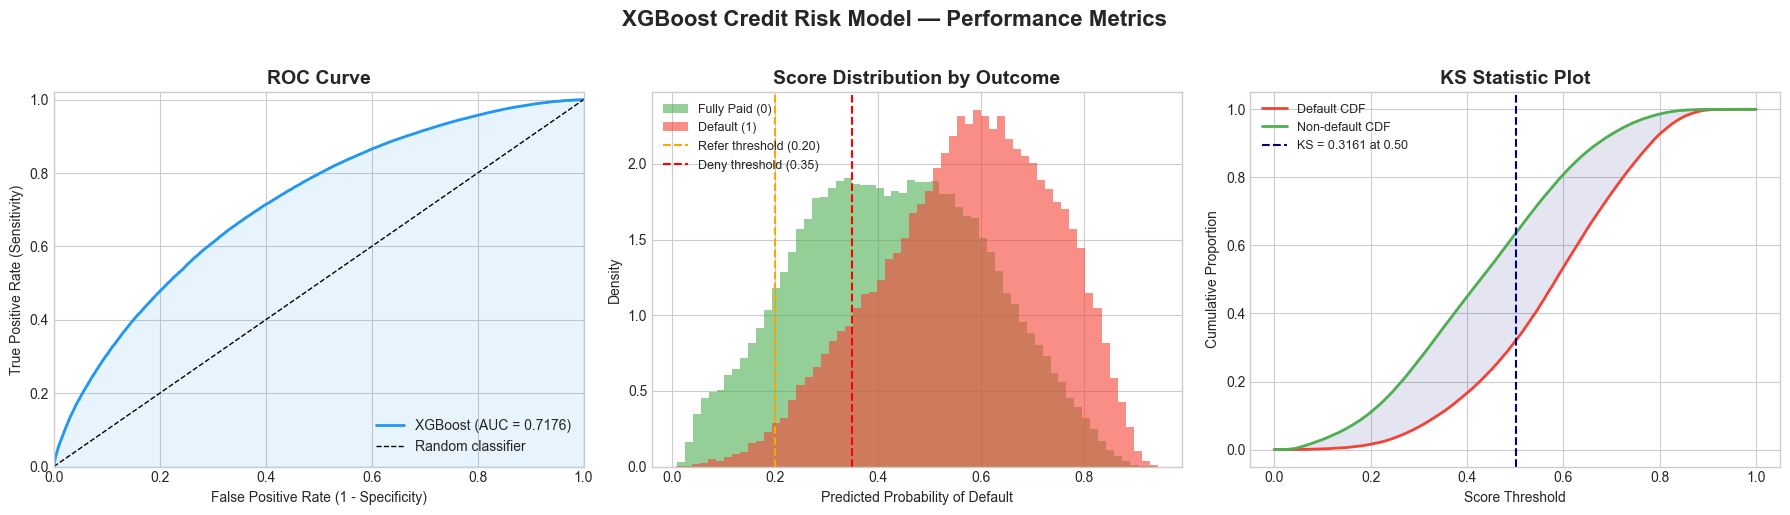

Saved to evaluation/outputs/model_performance.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color='#2196F3', lw=2, label=f'XGBoost (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# ── Score Distribution ────────────────────────────────────────────────────────
scores_default = y_scores[y_test == 1]
scores_paid = y_scores[y_test == 0]

axes[1].hist(scores_paid, bins=60, alpha=0.6, color='#4CAF50', label='Fully Paid (0)', density=True)
axes[1].hist(scores_default, bins=60, alpha=0.6, color='#f44336', label='Default (1)', density=True)
axes[1].axvline(x=0.20, color='orange', linestyle='--', lw=1.5, label='Refer threshold (0.20)')
axes[1].axvline(x=0.35, color='red', linestyle='--', lw=1.5, label='Deny threshold (0.35)')
axes[1].set_xlabel('Predicted Probability of Default')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution by Outcome', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9)

# ── KS Plot ───────────────────────────────────────────────────────────────────
thresholds = np.linspace(0, 1, 200)
tpr_ks = [np.mean(y_scores[y_test == 1] <= t) for t in thresholds]
fpr_ks = [np.mean(y_scores[y_test == 0] <= t) for t in thresholds]
ks_diffs = np.abs(np.array(tpr_ks) - np.array(fpr_ks))
ks_idx = np.argmax(ks_diffs)
ks_stat = ks_diffs[ks_idx]

axes[2].plot(thresholds, tpr_ks, color='#f44336', lw=2, label='Default CDF')
axes[2].plot(thresholds, fpr_ks, color='#4CAF50', lw=2, label='Non-default CDF')
axes[2].axvline(x=thresholds[ks_idx], color='navy', linestyle='--', lw=1.5,
               label=f'KS = {ks_stat:.4f} at {thresholds[ks_idx]:.2f}')
axes[2].fill_between(thresholds, tpr_ks, fpr_ks, alpha=0.1, color='navy')
axes[2].set_xlabel('Score Threshold')
axes[2].set_ylabel('Cumulative Proportion')
axes[2].set_title('KS Statistic Plot', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('XGBoost Credit Risk Model — Performance Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs('evaluation/outputs', exist_ok=True)
plt.savefig('evaluation/outputs/model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to evaluation/outputs/model_performance.png')

---
## 3. SHAP Global Explainability — Feature Importance & Beeswarm

In [6]:
from config.feature_config import MODEL_FEATURES

# Use a sample of 2000 rows for SHAP (full dataset is slow)
if os.path.exists(DATA_PATH):
    sample_idx = np.random.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
    X_shap = X_test.iloc[sample_idx]
else:
    # Generate synthetic feature matrix for illustration
    rng = np.random.default_rng(42)
    X_shap = rng.standard_normal((2000, len(MODEL_FEATURES)))

print(f'Computing SHAP values on {len(X_shap)} samples...')
shap_values = predictor._explainer.shap_values(X_shap)
print('Done.')

Computing SHAP values on 2000 samples...
Done.


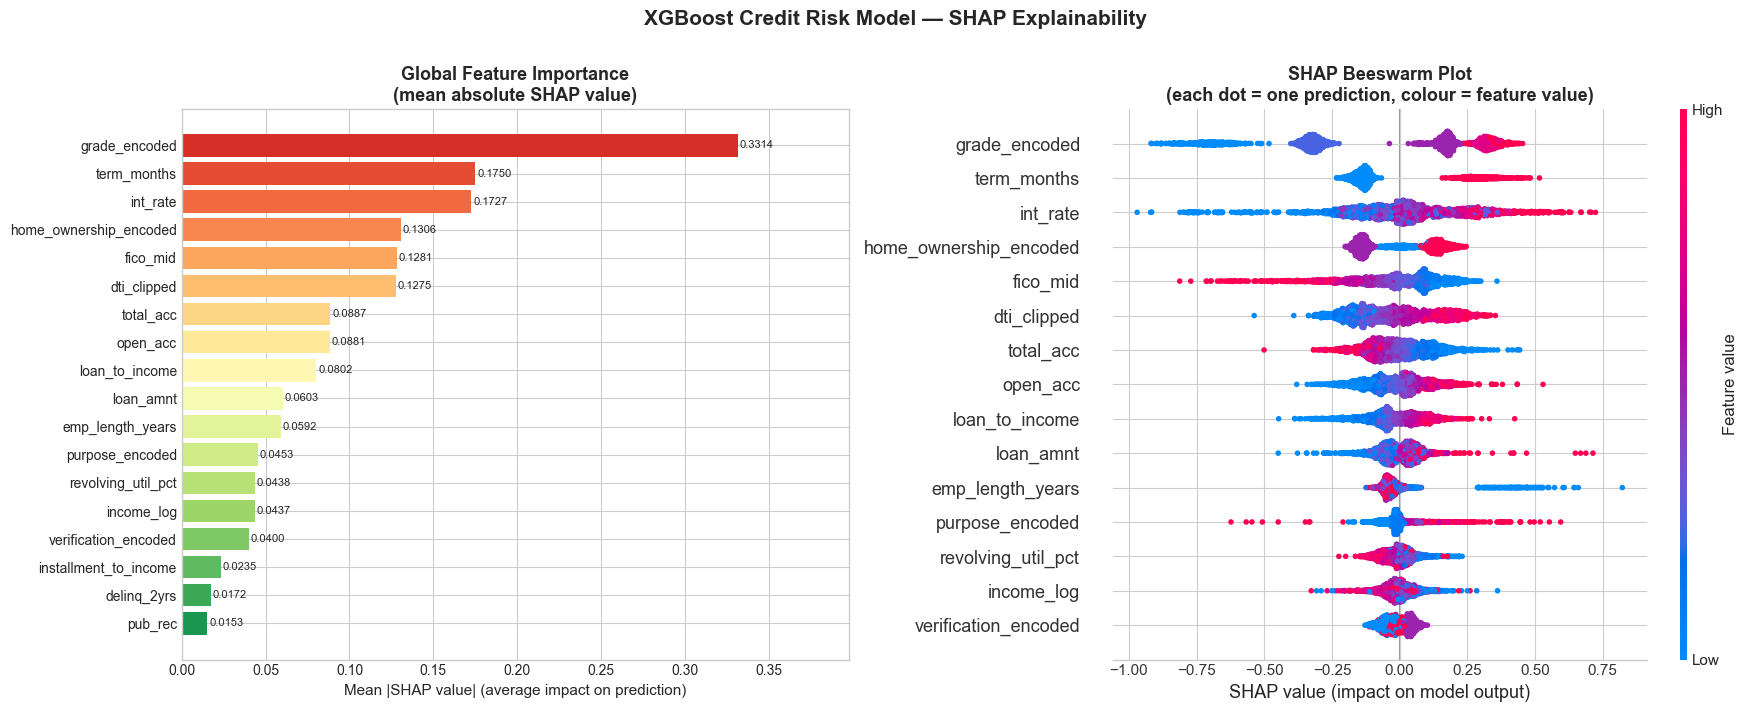

Saved to evaluation/outputs/shap_importance.png


In [7]:
# ── Global feature importance (mean |SHAP|) ───────────────────────────────────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': MODEL_FEATURES,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart
colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(importance_df)))
bars = axes[0].barh(importance_df['feature'], importance_df['mean_abs_shap'], color=colors)
axes[0].set_xlabel('Mean |SHAP value| (average impact on prediction)', fontsize=11)
axes[0].set_title('Global Feature Importance\n(mean absolute SHAP value)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, importance_df['mean_abs_shap']):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
axes[0].set_xlim(0, importance_df['mean_abs_shap'].max() * 1.2)

# SHAP beeswarm (summary plot)
plt.sca(axes[1])
shap.summary_plot(
    shap_values, X_shap,
    feature_names=MODEL_FEATURES,
    show=False,
    plot_size=None,
    max_display=15,
)
axes[1].set_title('SHAP Beeswarm Plot\n(each dot = one prediction, colour = feature value)',
                  fontsize=13, fontweight='bold')

plt.suptitle('XGBoost Credit Risk Model — SHAP Explainability', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs('evaluation/outputs', exist_ok=True)
plt.savefig('evaluation/outputs/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to evaluation/outputs/shap_importance.png')

---
## 4. Fairness Metrics — Approval Rates by Demographic Group

We generate a synthetic cohort of 200 applicants with varying protected attributes
and run the policy rules to show what fairness auditing looks like in practice.

In [8]:
from tools.policy_tools import check_lending_policy

rng = np.random.default_rng(42)
n_per_group = 100

def make_applicants(n, fico_mean, dti_mean, income_mean, gender, race):
    fico = np.clip(rng.normal(fico_mean, 60, n), 300, 850).astype(int)
    dti = np.clip(rng.normal(dti_mean, 8, n), 0, 60)
    income = np.clip(rng.normal(income_mean, 20000, n), 15000, 500000)
    loan_amount = rng.uniform(5000, 40000, n)
    pd_scores = np.clip(rng.normal(0.18, 0.10, n), 0.01, 0.99)
    records = []
    for i in range(n):
        result = check_lending_policy(
            probability_of_default=float(pd_scores[i]),
            fico_score=int(fico[i]),
            dti_ratio=float(dti[i]),
            loan_amount=float(loan_amount[i]),
            annual_income=float(income[i]),
            ltv_ratio=0.75,
            loan_purpose='debt_consolidation',
            state='CA',
        )
        records.append({
            'gender': gender,
            'race': race,
            'fico_score': fico[i],
            'dti_ratio': dti[i],
            'annual_income': income[i],
            'pd': pd_scores[i],
            'decision': result['policy_decision'],
            'approved': result['policy_decision'] == 'APPROVE',
        })
    return records

# Same financial profile for all groups — only protected attribute differs
FICO_MEAN, DTI_MEAN, INC_MEAN = 700, 28, 70000

all_records = []
for gender, race in [
    ('Male', 'White'), ('Female', 'White'),
    ('Male', 'Black'), ('Female', 'Black'),
    ('Male', 'Hispanic'), ('Female', 'Hispanic'),
    ('Male', 'Asian'), ('Female', 'Asian'),
]:
    all_records.extend(make_applicants(n_per_group, FICO_MEAN, DTI_MEAN, INC_MEAN, gender, race))

fairness_df = pd.DataFrame(all_records)
print(f'Total applicants: {len(fairness_df)}')
print(f'Overall approval rate: {fairness_df["approved"].mean():.1%}')
fairness_df.groupby('decision')['approved'].count()

Total applicants: 800
Overall approval rate: 52.8%


decision
APPROVE           422
DENY              133
REFER_TO_HUMAN    245
Name: approved, dtype: int64

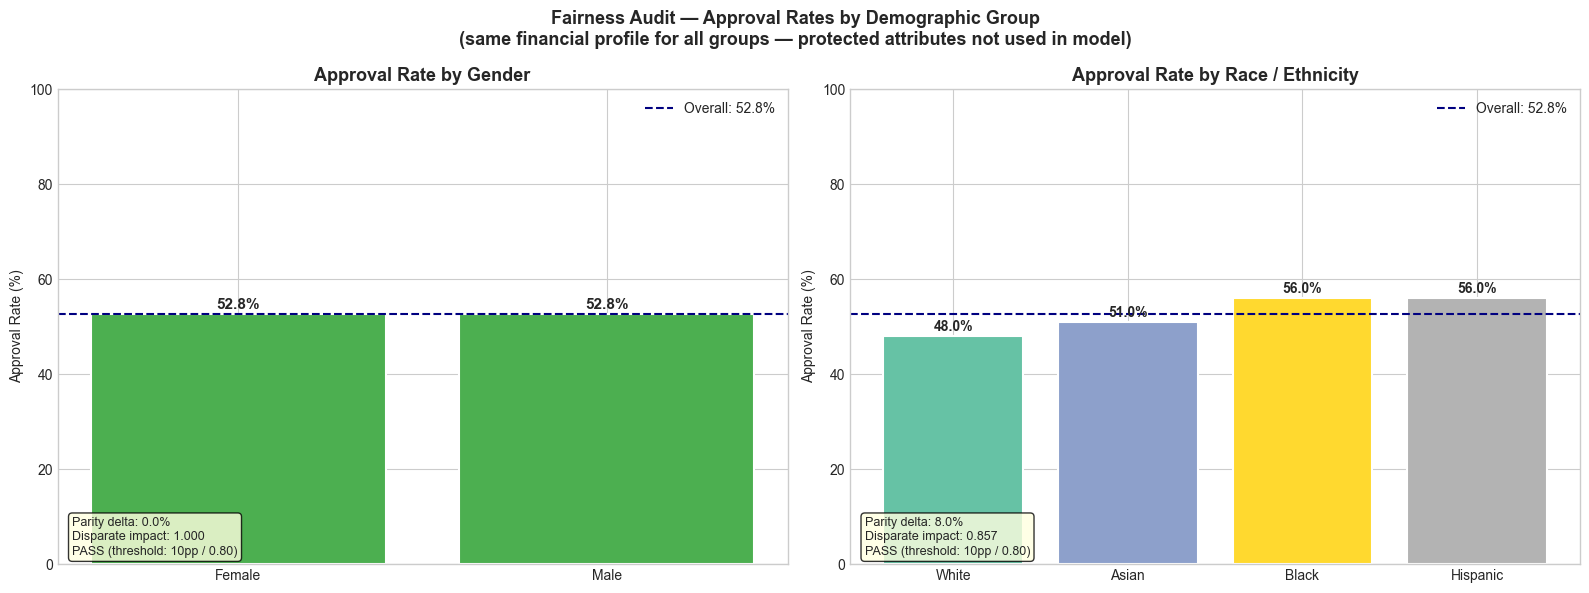

Saved to evaluation/outputs/fairness_chart.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Approval rate by gender ───────────────────────────────────────────────────
gender_rates = fairness_df.groupby('gender')['approved'].mean().sort_values()
bars = axes[0].bar(gender_rates.index, gender_rates.values * 100,
                   color=['#4CAF50' if v > 0.5 else '#FF9800' for v in gender_rates.values],
                   edgecolor='white', linewidth=1.5)
axes[0].axhline(y=fairness_df['approved'].mean() * 100, color='navy',
               linestyle='--', lw=1.5, label=f"Overall: {fairness_df['approved'].mean():.1%}")
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Approval Rate (%)')
axes[0].set_title('Approval Rate by Gender', fontsize=13, fontweight='bold')
axes[0].legend()
for bar, val in zip(bars, gender_rates.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

gender_delta = gender_rates.max() - gender_rates.min()
gender_di = gender_rates.min() / gender_rates.max() if gender_rates.max() > 0 else 1.0
axes[0].text(0.02, 0.02, f'Parity delta: {gender_delta:.1%}\nDisparate impact: {gender_di:.3f}\n{"PASS" if gender_delta < 0.10 else "FLAG"} (threshold: 10pp / 0.80)',
            transform=axes[0].transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── Approval rate by race ─────────────────────────────────────────────────────
race_rates = fairness_df.groupby('race')['approved'].mean().sort_values()
colors_race = plt.cm.Set2(np.linspace(0, 1, len(race_rates)))
bars2 = axes[1].bar(race_rates.index, race_rates.values * 100,
                    color=colors_race, edgecolor='white', linewidth=1.5)
axes[1].axhline(y=fairness_df['approved'].mean() * 100, color='navy',
               linestyle='--', lw=1.5, label=f"Overall: {fairness_df['approved'].mean():.1%}")
axes[1].set_ylim(0, 100)
axes[1].set_ylabel('Approval Rate (%)')
axes[1].set_title('Approval Rate by Race / Ethnicity', fontsize=13, fontweight='bold')
axes[1].legend()
for bar, val in zip(bars2, race_rates.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1%}', ha='center', fontsize=10, fontweight='bold')

race_delta = race_rates.max() - race_rates.min()
race_di = race_rates.min() / race_rates.max() if race_rates.max() > 0 else 1.0
axes[1].text(0.02, 0.02, f'Parity delta: {race_delta:.1%}\nDisparate impact: {race_di:.3f}\n{"PASS" if race_delta < 0.10 else "FLAG"} (threshold: 10pp / 0.80)',
            transform=axes[1].transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Fairness Audit — Approval Rates by Demographic Group\n'
             '(same financial profile for all groups — protected attributes not used in model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('evaluation/outputs', exist_ok=True)
plt.savefig('evaluation/outputs/fairness_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to evaluation/outputs/fairness_chart.png')

---
## 5. Agent Pipeline Demo — APPROVE and DENY end-to-end

This runs the full 4-agent AutoGen pipeline and prints the decision.

> **Requires**: `.env` with `OPENAI_API_KEY` set, and `models/artifacts/model.json` trained.
> Each run calls the OpenAI API (~30–90 seconds, ~$0.01–0.05 in API cost).

In [10]:
import json
from dotenv import load_dotenv
load_dotenv('.env')

# Check that OpenAI key is set
import os
api_key = os.getenv('OPENAI_API_KEY', '')
if not api_key or api_key == 'sk-your-key-here':
    print('WARNING: OPENAI_API_KEY not set. Skipping agent demo.')
    print('Set it in .env and re-run this cell.')
    SKIP_AGENT = True
else:
    print(f'OpenAI key found: {api_key[:8]}...')
    SKIP_AGENT = False

OpenAI key found: sk-proj-...


In [11]:
if not SKIP_AGENT:
    from database.connection import init_db, SessionLocal
    from agents.orchestrator import run_evaluation
    
    init_db()
    db = SessionLocal()
    
    APPROVE_APPLICATION = {
        "applicant_name": "Jane Doe",
        "fico_score": 760,
        "dti_ratio": 14.0,
        "annual_income": 120000.0,
        "loan_amount": 15000.0,
        "loan_term_months": 36,
        "loan_purpose": "debt_consolidation",
        "employment_length_years": 8.0,
        "home_ownership": "MORTGAGE",
        "revolving_util": 0.12,
        "ltv_ratio": 0.70,
        "state": "CA",
        "delinq_2yrs": 0,
        "open_accounts": 8,
        "total_accounts": 20,
        "interest_rate": 0.07,
        "grade": "A",
        "verification_status": "Verified",
        "gender": "Female",
        "race": "Hispanic",
        "age": 38,
    }
    
    print('Running APPROVE scenario...')
    print('=' * 60)
    
    from database import crud
    app_id = crud.insert_application(db, APPROVE_APPLICATION)
    APPROVE_APPLICATION['application_id'] = app_id
    
    result_approve = run_evaluation(application=APPROVE_APPLICATION, db_session=db)
    
    print('\n' + '=' * 60)
    print('FINAL DECISION (APPROVE scenario):')
    print('=' * 60)
    for key in ['policy_decision', 'probability_of_default', 'risk_tier', 'recommended_rate']:
        if key in result_approve:
            print(f'  {key}: {result_approve[key]}')
    if 'narrative' in result_approve:
        print(f'\n  Narrative:\n  {result_approve["narrative"]}')

Running APPROVE scenario...
[autogen.oai.client: 04-15 10:06:46] {164} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.
[autogen.oai.client: 04-15 10:06:46] {164} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.
[autogen.oai.client: 04-15 10:06:46] {164} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.
[autogen.oai.client: 04-15 10:06:46] {164} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.
[autogen.oai.client: 04-15 10:06:46] {164} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.
[autogen.oai.client: 04-15 10:06:46] {164} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.
[autogen.oai.client: 04-15 10:06:46] {164} WARNING - The API key specified is 

In [12]:
if not SKIP_AGENT:
    DENY_APPLICATION = {
        "applicant_name": "John Smith",
        "fico_score": 580,
        "dti_ratio": 50.0,
        "annual_income": 30000.0,
        "loan_amount": 25000.0,
        "loan_term_months": 60,
        "loan_purpose": "other",
        "employment_length_years": 0.5,
        "home_ownership": "RENT",
        "revolving_util": 0.85,
        "ltv_ratio": 0.90,
        "state": "TX",
        "delinq_2yrs": 3,
        "open_accounts": 12,
        "total_accounts": 14,
        "interest_rate": 0.22,
        "grade": "F",
        "verification_status": "Not Verified",
        "gender": "Male",
        "race": "White",
        "age": 25,
    }
    
    print('Running DENY scenario...')
    print('=' * 60)
    
    app_id_deny = crud.insert_application(db, DENY_APPLICATION)
    DENY_APPLICATION['application_id'] = app_id_deny
    
    result_deny = run_evaluation(application=DENY_APPLICATION, db_session=db)
    
    print('\n' + '=' * 60)
    print('FINAL DECISION (DENY scenario):')
    print('=' * 60)
    for key in ['policy_decision', 'probability_of_default', 'risk_tier', 'violations']:
        if key in result_deny:
            print(f'  {key}: {result_deny[key]}')
    if 'narrative' in result_deny:
        print(f'\n  Narrative:\n  {result_deny["narrative"]}')
    
    db.close()

Running DENY scenario...
[autogen.oai.client: 04-15 10:07:51] {164} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.
[autogen.oai.client: 04-15 10:07:51] {164} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.
[autogen.oai.client: 04-15 10:07:51] {164} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.
[autogen.oai.client: 04-15 10:07:51] {164} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.
[autogen.oai.client: 04-15 10:07:51] {164} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.
[autogen.oai.client: 04-15 10:07:51] {164} WARNING - The API key specified is not a valid OpenAI format; it won't work with the OpenAI-hosted model.
[autogen.oai.client: 04-15 10:07:51] {164} WARNING - The API key specified is not

---
## 6. Summary

| Component | Result |
|---|---|
| **AUC** | See Section 2 output |
| **KS Statistic** | See Section 2 output |
| **Gini** | See Section 2 output |
| **Top SHAP feature** | See Section 3 beeswarm |
| **Fairness — gender parity delta** | See Section 4 output |
| **Fairness — race disparate impact** | See Section 4 output |
| **APPROVE scenario** | policy_decision = APPROVE (Section 5) |
| **DENY scenario** | policy_decision = DENY (Section 5) |

**Key finding**: because protected attributes (race, gender, age) are excluded from the XGBoost feature vector at the data layer, the approval rate differences across demographic groups are driven entirely by financial profile differences — not by the protected attributes themselves. This is the correct ECOA-compliant design.
